In [ ]:
import nifty.re as jft
import jax
import jax.numpy as jnp
import jax.random as random

%matplotlib inline
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 100
jax.config.update("jax_enable_x64", True)
seed = 42
key = random.PRNGKey(seed)
dims = 100
distances = 0.01
grid = jft.correlated_field.make_grid(
dims, distances=distances, harmonic_type="fourier"
)

axis = jnp.arange(0, dims * distances, distances)
def amplitude_spectrum(k):
    return 2.5 / (5 + k**2)

k_lengths = grid.harmonic_grid.mode_lengths
amplitudes = amplitude_spectrum(k_lengths)
sqrt_hamonic_cov = amplitudes[grid.harmonic_grid.power_distributor]

class FixedPowerCorrelatedField(jft.Model):
    def __init__(self, sqrt_hamonic_cov, grid):
        self.sqrt_hamonic_cov = sqrt_hamonic_cov
        self.ht = jft.correlated_field.hartley
        self.harmonic_dvol = 1 / grid.total_volume

        super().__init__(
            domain=jax.ShapeDtypeStruct(shape=grid.shape, dtype=jnp.float64)
        )
    def __call__(self, x):
        return self.harmonic_dvol * self.ht(self.sqrt_hamonic_cov * x)
    
signal = FixedPowerCorrelatedField(sqrt_hamonic_cov, grid)

In [4]:
signal_response = signal

In [5]:
key, subkey = random.split(key)
pos_truth = jft.random_like(subkey, signal_response.domain)
signal_response_truth = signal_response(pos_truth)

In [6]:
noise_std = 0.3
noise_cov = lambda x: noise_std**2 * x
noise_cov_inv = lambda x: noise_std**-2 * x
key, subkey = random.split(key)
noise_truth = noise_std * jft.random_like(key, signal_response.target)

In [7]:
data = signal_response_truth + noise_truth

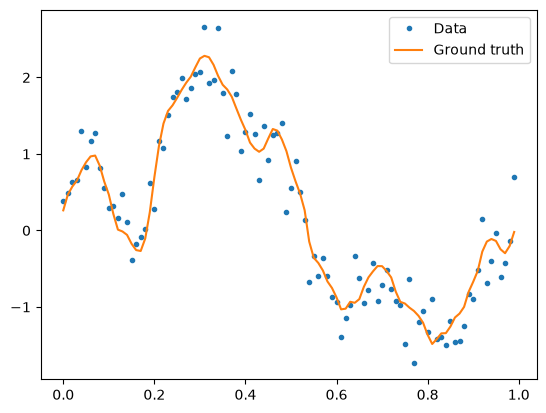

In [8]:
plt.plot(axis, data, ".", color="tab:blue", label="Data")
plt.plot(axis, signal(pos_truth), color="tab:orange", label="Ground truth")
plt.legend()
plt.show()

In [9]:
lh = jft.Gaussian(data, noise_cov_inv).amend(signal_response)

assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`
/home/genya/.venv/lib/python3.14/site-packages/nifty/re/model.py:190: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)


In [10]:
# The Wiener filter
delta = 1e-6
key, k_w = random.split(key)
samples, _ = jft.wiener_filter_posterior(
    likelihood=lh,
    key=k_w,
    n_samples=20,
    draw_linear_kwargs=dict(
    cg_name=None,
    cg_kwargs=dict(absdelta=delta * jft.size(lh.domain) / 10.0, maxiter=100),
    ),
)

In [11]:
post_mean, post_std = jft.mean_and_std(tuple(signal(s) for s in samples))

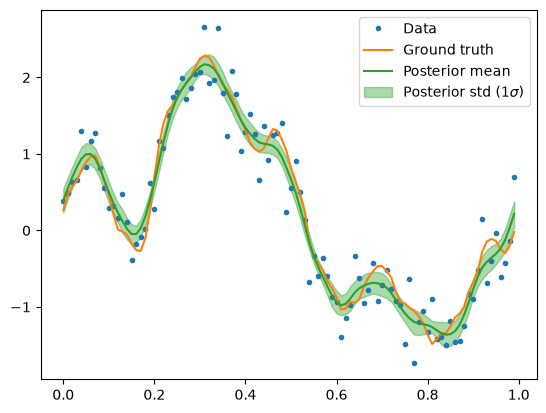

In [12]:
plt.plot(axis, data, ".", color="tab:blue", label="Data")
plt.plot(axis, signal(pos_truth), color="tab:orange", label="Ground truth")
plt.plot(axis, post_mean, label="Posterior mean", color="tab:green")
plt.fill_between(
    axis,
    post_mean- post_std,
    post_mean + post_std,
    color="tab:green",
    alpha=0.4,
    label=r"Posterior std (1$\sigma$)",
)
plt.legend()
plt.show()

In [14]:
class SignalResponse(jft.Model):
    def __init__(self, signal, sensitivity):
        self.signal = signal
        self.sensitivity = sensitivity
        super().__init__(domain=signal.domain)

    def __call__(self, x):
        return self.signal(x) * self.sensitivity

sensitivity = jnp.ones(shape=dims)
sensitivity = sensitivity.at[25:80].set(0.0)

signal_response = SignalResponse(signal, sensitivity)

In [15]:
noise_std = 0.1
noise_cov = lambda x: noise_std**2 * x
noise_cov_inv = lambda x: noise_std**-2 * x
signal_truth = signal(pos_truth)
signal_response_truth = signal_response(pos_truth)
key, subkey = random.split(key)
noise_true = noise_std * jft.random_like(subkey, signal_response.domain)
data = signal_response_truth + noise_true

In [16]:
lh = jft.Gaussian(data, noise_cov_inv).amend(signal_response)
key, subkey = random.split(key)
samples, info = jft.wiener_filter_posterior(
    lh,
    key=subkey,
    n_samples=20,
    draw_linear_kwargs=dict(cg_name=None, cg_kwargs=dict(absdelta=delta, 
    maxiter=100)),
)
post_mean, post_std = jft.mean_and_std(tuple(signal(s) for s in samples))

assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


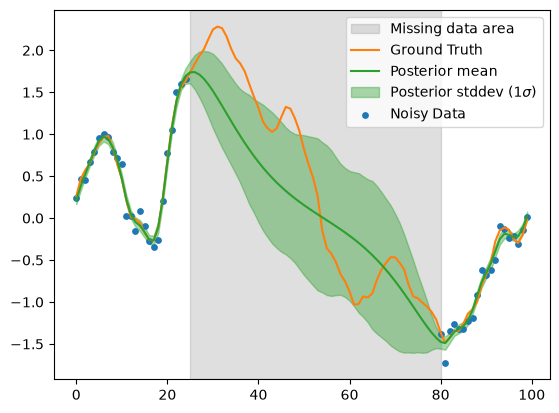

In [17]:
plt.axvspan(25, 80, color="gray", alpha=0.25, label="Missing data area")
plt.plot(jnp.arange(len(data)), signal_truth, color="tab:orange", label="Ground Truth")
plt.plot(jnp.arange(len(data)), post_mean, color="tab:green", label="Posterior mean")
plt.fill_between(
    range(post_mean.size),
    (post_mean- post_std),
    (post_mean + post_std),
    color="tab:green",
    alpha=0.4,
    label=r"Posterior stddev (1$\sigma$)",
)

data = data.at[25:80].set(jnp.nan) # Remove masked data from plotting
plt.scatter(jnp.arange(len(data)), data, label="Noisy Data", s=15, color="tab:blue")
plt.legend()
plt.show()